# Proyecto final — Clasificación de la visibilidad competitiva de artistas en Spotify Charts

**Curso:** Análisis de grandes volúmenes de datos  
**Equipo:** 51  
**Autores:** Fernando Arango Gaviria (A01797660), Jose Luis Armenta Mandujano (A01796933), Demenard Gardy Armand (A01797139) y Ricardo Ismael Vega Aguilar (A01796617)  
**Dataset:** Spotify Charts Daily Updated (`charts_artists_daily.csv`)  
**Tecnología principal:** PySpark

## Resumen del proyecto

Este notebook integra las etapas desarrolladas durante el curso para estudiar una tarea de aprendizaje aplicada a grandes volúmenes de datos: clasificar cada observación diaria de un artista como `Top` (`rank <= 50`) o `Estable` (`rank > 50`). La población se caracteriza por antigüedad, alcance geográfico y posición competitiva; después se construye una muestra estratificada proporcional cercana a 200,000 registros.

El modelo principal es un `RandomForestClassifier`. Se realiza una búsqueda ligera de hiperparámetros, se selecciona la configuración con mejor AUC-ROC y F1 ponderado, y se estima su estabilidad mediante validación cruzada estratificada de cinco pliegues. Como análisis complementario, `KMeans` identifica perfiles latentes de permanencia, alcance y posición. El objetivo es explicativo: reconocer patrones asociados con la visibilidad competitiva, no pronosticar posiciones futuras.

In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession, functions as F, Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator,
    ClusteringEvaluator,
)
from pyspark.ml.functions import vector_to_array

try:
    from sklearn.metrics import roc_curve, auc
except Exception:
    roc_curve = None
    auc = None

SEED = 42
TARGET_N = 200_000
K_FOLDS = 5
HYPERPARAMETERS = [
    {'numTrees': 50, 'maxDepth': 6},
    {'numTrees': 50, 'maxDepth': 8},
    {'numTrees': 100, 'maxDepth': 6},
    {'numTrees': 100, 'maxDepth': 8},
]

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 120

In [2]:
spark = (
    SparkSession.builder
    .appName('ProyectoFinal_Equipo51')
    .master('local[*]')
    .config('spark.sql.shuffle.partitions', '64')
    .config('spark.driver.memory', '8g')
    .config('spark.sql.execution.arrow.pyspark.enabled', 'true')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')

BASE_DIR = Path.cwd()
if (BASE_DIR / 'spotify_project').exists():
    PROJECT_DIR = BASE_DIR / 'spotify_project'
elif BASE_DIR.name == 'spotify_project':
    PROJECT_DIR = BASE_DIR
else:
    PROJECT_DIR = BASE_DIR.parent if BASE_DIR.parent.name == 'spotify_project' else BASE_DIR

RAW_PATH = PROJECT_DIR / 'raw' / 'charts_artists_daily.csv'
REPORT_DIR = PROJECT_DIR / 'report'
ASSET_DIR = REPORT_DIR / 'assets'
REPORT_DIR.mkdir(exist_ok=True)
ASSET_DIR.mkdir(exist_ok=True)

assert RAW_PATH.exists(), f'No se encontró el dataset: {RAW_PATH}'
print(f'Spark: {spark.version}')
print(f'Proyecto: {PROJECT_DIR}')
print(f'Dataset: {RAW_PATH}')
print(f'Salidas del reporte: {REPORT_DIR}')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/25 18:20:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 4.1.1
Proyecto: /Users/armand501/Library/Mobile Documents/com~apple~CloudDocs/My Documents/Maestria/Análisis de grandes volúmenes de datos/spotify_project
Dataset: /Users/armand501/Library/Mobile Documents/com~apple~CloudDocs/My Documents/Maestria/Análisis de grandes volúmenes de datos/spotify_project/raw/charts_artists_daily.csv
Salidas del reporte: /Users/armand501/Library/Mobile Documents/com~apple~CloudDocs/My Documents/Maestria/Análisis de grandes volúmenes de datos/spotify_project/report


## 1. Lectura, auditoría y delimitación de la población

La unidad de análisis es un registro artista-país-fecha. Se inspeccionan esquema, volumen, cobertura temporal, nulos críticos y duplicados exactos. Venezuela se excluye porque el trabajo exploratorio previo identificó un patrón de carga anómalo. La ventana de aprendizaje comienza el 21 de octubre de 2022, después de un año de historial, para que la distinción `Nuevo`/`Veterano` no clasifique artificialmente a todos los artistas como nuevos.

In [3]:
raw = (
    spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .csv(str(RAW_PATH))
    .select(
        F.col('date').cast('date').alias('date'),
        F.col('country').alias('country'),
        F.col('rank').cast('int').alias('rank'),
        F.col('uri').alias('artist_uri'),
        F.col('artist_name').alias('artist_name'),
        F.col('days_on_chart').cast('int').alias('days_on_chart'),
    )
)

print('Esquema base:')
raw.printSchema()
print(f'Registros originales: {raw.count():,}')


n_original = raw.count()
date_bounds = raw.agg(F.min('date').alias('min_date'), F.max('date').alias('max_date')).first()
null_audit = raw.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in ['date', 'country', 'rank', 'artist_uri', 'days_on_chart']
]).toPandas()
duplicate_count = raw.groupBy('date', 'country', 'rank', 'artist_uri', 'days_on_chart').count().filter(F.col('count') > 1).count()

print(f'Cobertura temporal: {date_bounds.min_date} a {date_bounds.max_date}')
print('Nulos críticos:')
print(null_audit.to_string(index=False))
print(f'Grupos de duplicados exactos en variables clave: {duplicate_count:,}')

Esquema base:
root
 |-- date: date (nullable = true)
 |-- country: string (nullable = true)
 |-- rank: integer (nullable = true)
 |-- artist_uri: string (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- days_on_chart: integer (nullable = true)



Registros originales: 22,711,258


Cobertura temporal: 2021-10-21 a 2026-05-02
Nulos críticos:


 date  country  rank  artist_uri  days_on_chart
    0        0     0           0              0
Grupos de duplicados exactos en variables clave: 0


## 2. Caracterización, particionamiento y muestra representativa

La población evaluable se caracteriza mediante tres ejes:

- `artist_tenure`: `Veterano` cuando el historial máximo supera 365 días; `Nuevo` en caso contrario.
- `artist_scope`: `Global` cuando el artista aparece en más de 10 países; `Local` en caso contrario.
- `rank_tier`: `Top` para posiciones 1–50 y `Estable` para posiciones 51–200.

Las combinaciones generan ocho estratos. Se aplica muestreo aleatorio estratificado proporcional sin reemplazo, con asignación `n_i = n(N_i/N)`. Esto conserva la heterogeneidad observada y evita que los perfiles mayoritarios borren casos menos frecuentes.

In [4]:
# Se conserva la misma base metodológica de las Actividades 3 y 4.
raw_clean = raw.filter(F.col('country') != 'VE')
filtered = raw_clean.filter(F.col('date') >= F.lit('2022-10-21'))
n_total = filtered.count()
print(f'Registros tras excluir VE y aplicar ventana evaluable: {n_total:,}')

artist_profile = (
    raw_clean.groupBy('artist_uri')
    .agg(
        F.countDistinct('country').alias('country_count_by_artist'),
        F.max('days_on_chart').alias('max_days_on_chart'),
    )
    .withColumn(
        'artist_tenure',
        F.when(F.col('max_days_on_chart') > 365, F.lit('Veterano')).otherwise(F.lit('Nuevo')),
    )
    .withColumn(
        'artist_scope',
        F.when(F.col('country_count_by_artist') > 10, F.lit('Global')).otherwise(F.lit('Local')),
    )
)

partitioned = (
    filtered.join(artist_profile, on='artist_uri', how='left')
    .withColumn('rank_tier', F.when(F.col('rank') <= 50, F.lit('Top')).otherwise(F.lit('Estable')))
    .withColumn('partition_id', F.concat_ws('-', 'artist_tenure', 'artist_scope', 'rank_tier'))
    .cache()
)
print(f'Población particionada: {partitioned.count():,}')


Registros tras excluir VE y aplicar ventana evaluable: 17,914,239


Población particionada: 17,914,239


In [5]:
strata = (
    partitioned.groupBy('partition_id').count()
    .withColumn('probability', F.col('count') / F.lit(n_total))
    .orderBy(F.desc('count'))
)

strata_pd = strata.toPandas()
strata_pd['n_i'] = (strata_pd['probability'] * TARGET_N).round().astype(int)
strata_pd['fraction'] = (strata_pd['n_i'] / strata_pd['count']).clip(upper=1.0)

print('Distribución de estratos en P y asignación de muestra:')
print(strata_pd.to_string(index=False))

fractions = dict(zip(strata_pd['partition_id'], strata_pd['fraction']))
M = partitioned.sampleBy('partition_id', fractions=fractions, seed=SEED).cache()
n_M = M.count()
print(f'\nTamaño final de M: {n_M:,}')


sample_strata = M.groupBy('partition_id').count().orderBy('partition_id').toPandas()
sample_strata['prop_M'] = sample_strata['count'] / sample_strata['count'].sum()
strata_compare = (
    strata_pd[['partition_id', 'count', 'probability']]
    .rename(columns={'count': 'count_P', 'probability': 'prop_P'})
    .merge(sample_strata.rename(columns={'count': 'count_M'}), on='partition_id')
)
strata_compare['abs_diff_pct'] = (strata_compare['prop_P'] - strata_compare['prop_M']).abs() * 100
print('\nComparación de proporciones P vs M:')
print(strata_compare.round(4).to_string(index=False))

assert strata_pd['partition_id'].nunique() == 8, 'La población no contiene los ocho estratos esperados.'
assert sample_strata['partition_id'].nunique() == 8, 'La muestra no contiene los ocho estratos esperados.'
assert abs(n_M - TARGET_N) / TARGET_N < 0.03, 'El tamaño muestral se aleja más de 3% del objetivo.'

Distribución de estratos en P y asignación de muestra:
           partition_id   count  probability   n_i  fraction
Veterano-Global-Estable 7681082     0.428770 85754  0.011164
 Veterano-Local-Estable 4613304     0.257522 51504  0.011164
    Veterano-Global-Top 2730816     0.152438 30488  0.011164
     Veterano-Local-Top 1752364     0.097820 19564  0.011164
    Nuevo-Local-Estable  789060     0.044047  8809  0.011164
   Nuevo-Global-Estable  253107     0.014129  2826  0.011165
        Nuevo-Local-Top   47955     0.002677   535  0.011156
       Nuevo-Global-Top   46551     0.002599   520  0.011171



Tamaño final de M: 200,033



Comparación de proporciones P vs M:
           partition_id  count_P  prop_P  count_M  prop_M  abs_diff_pct
Veterano-Global-Estable  7681082  0.4288    86141  0.4306        0.1864
 Veterano-Local-Estable  4613304  0.2575    51391  0.2569        0.0609
    Veterano-Global-Top  2730816  0.1524    30465  0.1523        0.0138
     Veterano-Local-Top  1752364  0.0978    19539  0.0977        0.0141
    Nuevo-Local-Estable   789060  0.0440     8715  0.0436        0.0479
   Nuevo-Global-Estable   253107  0.0141     2737  0.0137        0.0446
        Nuevo-Local-Top    47955  0.0027      509  0.0025        0.0132
       Nuevo-Global-Top    46551  0.0026      536  0.0027        0.0081


In [6]:
M_clean = (
    M.dropna(subset=[
        'country', 'rank', 'days_on_chart', 'max_days_on_chart',
        'country_count_by_artist', 'artist_tenure', 'artist_scope', 'rank_tier', 'partition_id',
    ])
    .withColumn('id', F.monotonically_increasing_id())
    .cache()
)
n_M_clean = M_clean.count()
print(f'Registros de M después de limpieza mínima: {n_M_clean:,}')

critical_nulls = M.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in ['country', 'rank', 'days_on_chart', 'max_days_on_chart', 'country_count_by_artist', 'rank_tier']
])
critical_nulls.show()


assert n_M_clean == n_M, 'La limpieza mínima eliminó registros; revisar campos críticos.'
assert M_clean.select('id').distinct().count() == n_M_clean, 'Los identificadores no son únicos.'

Registros de M después de limpieza mínima: 200,033


+-------+----+-------------+-----------------+-----------------------+---------+
|country|rank|days_on_chart|max_days_on_chart|country_count_by_artist|rank_tier|
+-------+----+-------------+-----------------+-----------------------+---------+
|      0|   0|            0|                0|                      0|        0|
+-------+----+-------------+-----------------+-----------------------+---------+



## Construcción de k-folds

Cada fold se construye dentro de `partition_id`, no sobre la muestra completa sin control. Primero se ordenan los registros de cada partición con una semilla fija; después se asigna `fold_id = (row_number - 1) mod 5`. Esto distribuye los registros de cada estrato entre los cinco pliegues de manera casi uniforme, mantiene la representatividad de `M_i` y evita que un fold quede dominado por una sola clase o tipo de artista.


In [7]:
fold_window = Window.partitionBy('partition_id').orderBy(F.rand(SEED), F.col('artist_uri'), F.col('date'))
M_folds = (
    M_clean
    .withColumn('row_in_partition', F.row_number().over(fold_window))
    .withColumn('fold_id', ((F.col('row_in_partition') - F.lit(1)) % F.lit(K_FOLDS)).cast('int'))
    .drop('row_in_partition')
    .cache()
)

fold_counts = (
    M_folds.groupBy('fold_id').count()
    .withColumn('pct_M', F.round(F.col('count') / F.lit(n_M_clean) * 100, 2))
    .orderBy('fold_id')
    .toPandas()
)
print('Tamaño por fold:')
print(fold_counts.to_string(index=False))

fold_strata = (
    M_folds.groupBy('fold_id', 'partition_id').count()
    .orderBy('fold_id', 'partition_id')
    .toPandas()
)
fold_pivot = fold_strata.pivot(index='partition_id', columns='fold_id', values='count').fillna(0).astype(int)
print('\nDistribución de particiones por fold:')
print(fold_pivot)


Tamaño por fold:
 fold_id  count  pct_M
       0  40010   20.0
       1  40007   20.0
       2  40006   20.0
       3  40006   20.0
       4  40004   20.0



Distribución de particiones por fold:
fold_id                      0      1      2      3      4
partition_id                                              
Nuevo-Global-Estable       548    548    547    547    547
Nuevo-Global-Top           108    107    107    107    107
Nuevo-Local-Estable       1743   1743   1743   1743   1743
Nuevo-Local-Top            102    102    102    102    101
Veterano-Global-Estable  17229  17228  17228  17228  17228
Veterano-Global-Top       6093   6093   6093   6093   6093
Veterano-Local-Estable   10279  10278  10278  10278  10278
Veterano-Local-Top        3908   3908   3908   3908   3907


In [8]:
fold_integrity = {
    'folds_distintos': M_folds.select('fold_id').distinct().count(),
    'registros_asignados': M_folds.count(),
    'ids_distintos': M_folds.select('id').distinct().count(),
    'particiones_por_fold_min': M_folds.groupBy('fold_id').agg(F.countDistinct('partition_id').alias('n')).agg(F.min('n')).first()[0],
    'particiones_totales': M_folds.select('partition_id').distinct().count(),
}
print(fold_integrity)
assert fold_integrity['folds_distintos'] == K_FOLDS
assert fold_integrity['registros_asignados'] == n_M_clean
assert fold_integrity['ids_distintos'] == n_M_clean
assert fold_integrity['particiones_por_fold_min'] == fold_integrity['particiones_totales']

assert int(fold_counts['count'].max() - fold_counts['count'].min()) <= 10, 'Los folds no están balanceados.'

{'folds_distintos': 5, 'registros_asignados': 200033, 'ids_distintos': 200033, 'particiones_por_fold_min': 8, 'particiones_totales': 8}


## 3. Preparación de variables y control de fuga de información

Las variables predictoras describen permanencia, alcance y contexto del mercado. `rank` se excluye de manera explícita porque la etiqueta `rank_tier` se deriva directamente de esa variable; incluirla produciría fuga de información y métricas artificialmente altas. Las categorías se indexan dentro de un pipeline reproducible y las mismas transformaciones se utilizan en todos los experimentos.

In [9]:
country_idx = StringIndexer(inputCol='country', outputCol='country_idx', handleInvalid='keep')
tenure_idx = StringIndexer(inputCol='artist_tenure', outputCol='tenure_idx', handleInvalid='keep')
scope_idx = StringIndexer(inputCol='artist_scope', outputCol='scope_idx', handleInvalid='keep')
label_idx = StringIndexer(inputCol='rank_tier', outputCol='label', handleInvalid='error')

feature_cols = [
    'days_on_chart',
    'max_days_on_chart',
    'country_count_by_artist',
    'country_idx',
    'tenure_idx',
    'scope_idx',
]
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')

prep_pipeline = Pipeline(stages=[country_idx, tenure_idx, scope_idx, label_idx, assembler])
prep_model = prep_pipeline.fit(M_folds)
M_features = (
    prep_model.transform(M_folds)
    .select('id', 'fold_id', 'features', 'label', 'rank_tier', 'partition_id', *feature_cols)
    .cache()
)
print(f'Registros con features y fold: {M_features.count():,}')
M_features.show(5, truncate=False)

label_lookup = (
    M_features.select('label', 'rank_tier')
    .distinct()
    .toPandas()
    .sort_values('label')
)
label_names = dict(zip(label_lookup['label'], label_lookup['rank_tier']))
positive_label = 1.0 if 1.0 in label_names else max(label_names)
positive_class = label_names.get(positive_label, str(positive_label))
print('Mapeo label -> clase:', label_names)
print(f'Clase positiva para ROC: {positive_class} (label={positive_label})')


assert 'rank' not in feature_cols, 'Fuga de información: rank no puede ser predictor.'
assert set(feature_cols) == {
    'days_on_chart', 'max_days_on_chart', 'country_count_by_artist',
    'country_idx', 'tenure_idx', 'scope_idx'
}

Registros con features y fold: 200,033
+------------+-------+-------------------------------+-----+---------+--------------------+-------------+-----------------+-----------------------+-----------+----------+---------+
|id          |fold_id|features                       |label|rank_tier|partition_id        |days_on_chart|max_days_on_chart|country_count_by_artist|country_idx|tenure_idx|scope_idx|
+------------+-------+-------------------------------+-----+---------+--------------------+-------------+-----------------+-----------------------+-----------+----------+---------+
|223338300647|0      |[7.0,119.0,36.0,26.0,1.0,0.0]  |0.0  |Estable  |Nuevo-Global-Estable|7            |119              |36                     |26.0       |1.0       |0.0      |
|8589935530  |1      |[71.0,201.0,36.0,47.0,1.0,0.0] |0.0  |Estable  |Nuevo-Global-Estable|71           |201              |36                     |47.0       |1.0       |0.0      |
|309237646208|2      |[158.0,364.0,55.0,20.0,1.0,0.0]|0.

Mapeo label -> clase: {0.0: 'Estable', 1.0: 'Top'}
Clase positiva para ROC: Top (label=1.0)


## 4. Selección de métricas y ajuste de hiperparámetros

La configuración se selecciona con un fold fijo de validación (`fold 0`) y los cuatro folds restantes para entrenamiento. Se comparan cuatro combinaciones de `numTrees` y `maxDepth`. El criterio principal es AUC-ROC, porque mide separación entre clases a diferentes umbrales; F1 ponderado funciona como desempate. También se reportan accuracy, precisión y recall ponderados para evitar una lectura basada en una sola métrica.

In [10]:
evaluators = {
    'accuracy': MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy'),
    'f1_weighted': MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1'),
    'precision_weighted': MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedPrecision'),
    'recall_weighted': MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedRecall'),
    'auc_roc': BinaryClassificationEvaluator(labelCol='label', rawPredictionCol='rawPrediction', metricName='areaUnderROC'),
}

def add_class_weights(train_df):
    label_counts = {row['label']: row['count'] for row in train_df.groupBy('label').count().collect()}
    n_tr = sum(label_counts.values())
    n_cls = len(label_counts)
    class_weight = {label: n_tr / (n_cls * count) for label, count in label_counts.items()}
    weight_expr = None
    for label, weight in class_weight.items():
        condition = F.col('label') == F.lit(label)
        weight_expr = F.when(condition, F.lit(weight)) if weight_expr is None else weight_expr.when(condition, F.lit(weight))
    return train_df.withColumn('weight', weight_expr.otherwise(F.lit(1.0))), class_weight

def evaluate_predictions(pred_df):
    return {name: evaluator.evaluate(pred_df) for name, evaluator in evaluators.items()}

def compute_confusion(pred_df, fold_id):
    return (
        pred_df.groupBy('label', 'prediction').count()
        .withColumn('fold_id', F.lit(fold_id))
        .toPandas()
    )

In [11]:
tune_train = M_features.filter(F.col('fold_id') != 0).cache()
tune_valid = M_features.filter(F.col('fold_id') == 0).cache()
tune_train_w, tuning_weights = add_class_weights(tune_train)
tune_train_w = tune_train_w.cache()

tuning_rows = []
for params in HYPERPARAMETERS:
    print(f"Probando numTrees={params['numTrees']}, maxDepth={params['maxDepth']}")
    candidate = RandomForestClassifier(
        featuresCol='features',
        labelCol='label',
        weightCol='weight',
        numTrees=params['numTrees'],
        maxDepth=params['maxDepth'],
        maxBins=128,
        seed=SEED,
    )
    candidate_model = candidate.fit(tune_train_w)
    candidate_pred = candidate_model.transform(tune_valid).cache()
    row = {**params, **evaluate_predictions(candidate_pred)}
    tuning_rows.append(row)
    print({k: round(v, 4) if isinstance(v, float) else v for k, v in row.items()})
    candidate_pred.unpersist()

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ['auc_roc', 'f1_weighted', 'numTrees', 'maxDepth'],
    ascending=[False, False, True, True],
).reset_index(drop=True)
best_params = {
    'numTrees': int(tuning_results.iloc[0]['numTrees']),
    'maxDepth': int(tuning_results.iloc[0]['maxDepth']),
}
print('\nResultados del ajuste:')
print(tuning_results.round(4).to_string(index=False))
print('\nConfiguración seleccionada:', best_params)

tune_train_w.unpersist()
tune_train.unpersist()
tune_valid.unpersist()

Probando numTrees=50, maxDepth=6


{'numTrees': 50, 'maxDepth': 6, 'accuracy': 0.7101, 'f1_weighted': 0.7238, 'precision_weighted': 0.7519, 'recall_weighted': 0.7101, 'auc_roc': 0.754}
Probando numTrees=50, maxDepth=8


{'numTrees': 50, 'maxDepth': 8, 'accuracy': 0.734, 'f1_weighted': 0.7468, 'precision_weighted': 0.7756, 'recall_weighted': 0.734, 'auc_roc': 0.7846}
Probando numTrees=100, maxDepth=6


{'numTrees': 100, 'maxDepth': 6, 'accuracy': 0.7115, 'f1_weighted': 0.7248, 'precision_weighted': 0.7521, 'recall_weighted': 0.7115, 'auc_roc': 0.753}
Probando numTrees=100, maxDepth=8


{'numTrees': 100, 'maxDepth': 8, 'accuracy': 0.7356, 'f1_weighted': 0.748, 'precision_weighted': 0.7754, 'recall_weighted': 0.7356, 'auc_roc': 0.7846}

Resultados del ajuste:
 numTrees  maxDepth  accuracy  f1_weighted  precision_weighted  recall_weighted  auc_roc
      100         8    0.7356       0.7480              0.7754           0.7356   0.7846
       50         8    0.7340       0.7468              0.7756           0.7340   0.7846
       50         6    0.7101       0.7238              0.7519           0.7101   0.7540
      100         6    0.7115       0.7248              0.7521           0.7115   0.7530

Configuración seleccionada: {'numTrees': 100, 'maxDepth': 8}


DataFrame[id: bigint, fold_id: int, features: vector, label: double, rank_tier: string, partition_id: string, days_on_chart: int, max_days_on_chart: int, country_count_by_artist: bigint, country_idx: double, tenure_idx: double, scope_idx: double]

## 5. Experimentación con validación cruzada

La configuración seleccionada se entrena cinco veces. En cada iteración, cuatro folds forman el entrenamiento y el fold restante funciona como prueba. Los pesos de clase se recalculan en cada entrenamiento. Se conservan métricas, probabilidades, matrices de confusión e importancia de variables para medir desempeño y variabilidad.

In [12]:
fold_metric_rows = []
baseline_metric_rows = []
confusion_frames = []
roc_frames = []
feature_importance_rows = []
fold_models = {}

for fold_id in range(K_FOLDS):
    print(f'\n=== Fold {fold_id} ===')
    train_df = M_features.filter(F.col('fold_id') != fold_id).cache()
    test_df = M_features.filter(F.col('fold_id') == fold_id).cache()
    train_w, class_weight = add_class_weights(train_df)
    train_w = train_w.cache()

    majority_label = train_df.groupBy('label').count().orderBy(F.desc('count')).first()['label']
    baseline_pred = test_df.withColumn('prediction', F.lit(float(majority_label)))
    baseline_metrics = {
        name: evaluator.evaluate(baseline_pred)
        for name, evaluator in evaluators.items()
        if name != 'auc_roc'
    }
    baseline_metrics.update({
        'auc_roc': 0.5,
        'fold_id': fold_id,
        'majority_label': float(majority_label),
    })
    baseline_metric_rows.append(baseline_metrics)

    rf = RandomForestClassifier(
        featuresCol='features',
        labelCol='label',
        weightCol='weight',
        numTrees=best_params['numTrees'],
        maxDepth=best_params['maxDepth'],
        maxBins=128,
        seed=SEED + fold_id,
    )
    model = rf.fit(train_w)
    pred = model.transform(test_df).cache()

    metrics = {name: evaluator.evaluate(pred) for name, evaluator in evaluators.items()}
    metrics.update({
        'fold_id': fold_id,
        'n_train': train_w.count(),
        'n_test': test_df.count(),
        'class_weight': {str(k): round(v, 4) for k, v in class_weight.items()},
    })
    fold_metric_rows.append(metrics)
    print({k: round(v, 4) if isinstance(v, float) else v for k, v in metrics.items() if k != 'class_weight'})

    confusion_frames.append(compute_confusion(pred, fold_id))

    prob_pd = (
        pred.select('fold_id', 'label', vector_to_array('probability').alias('probability_array'))
        .withColumn('prob_positive', F.col('probability_array')[int(positive_label)])
        .select('fold_id', 'label', 'prob_positive')
        .toPandas()
    )
    roc_frames.append(prob_pd)

    for feature, importance in zip(feature_cols, model.featureImportances.toArray()):
        feature_importance_rows.append({'fold_id': fold_id, 'feature': feature, 'importance': float(importance)})

    fold_models[fold_id] = model
    pred.unpersist()
    train_w.unpersist()
    train_df.unpersist()
    test_df.unpersist()

cv_metrics = pd.DataFrame(fold_metric_rows).sort_values('fold_id')
confusion_all = pd.concat(confusion_frames, ignore_index=True)
roc_all = pd.concat(roc_frames, ignore_index=True)
feature_importance_all = pd.DataFrame(feature_importance_rows)
baseline_metrics = pd.DataFrame(baseline_metric_rows).sort_values('fold_id')

oof_confusion = (
    confusion_all.groupby(['label', 'prediction'], as_index=False)['count'].sum()
)
per_class_rows = []
for label, class_name in label_names.items():
    tp = int(oof_confusion.loc[
        (oof_confusion['label'] == label) & (oof_confusion['prediction'] == label),
        'count',
    ].sum())
    fp = int(oof_confusion.loc[
        (oof_confusion['label'] != label) & (oof_confusion['prediction'] == label),
        'count',
    ].sum())
    fn = int(oof_confusion.loc[
        (oof_confusion['label'] == label) & (oof_confusion['prediction'] != label),
        'count',
    ].sum())
    support = tp + fn
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / support if support else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    per_class_rows.append({
        'label': float(label),
        'class': class_name,
        'support': support,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    })
per_class_metrics = pd.DataFrame(per_class_rows).sort_values('label')

metric_cols = ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted', 'auc_roc']
print('\nMétricas por fold:')
print(cv_metrics[['fold_id', 'n_train', 'n_test', *metric_cols]].round(4).to_string(index=False))
print('\nLínea base mayoritaria por fold:')
print(baseline_metrics[['fold_id', 'majority_label', *metric_cols]].round(4).to_string(index=False))
print('\nMétricas out-of-fold por clase:')
print(per_class_metrics.round(4).to_string(index=False))



=== Fold 0 ===


{'accuracy': 0.7356, 'f1_weighted': 0.748, 'precision_weighted': 0.7754, 'recall_weighted': 0.7356, 'auc_roc': 0.7846, 'fold_id': 0, 'n_train': 160023, 'n_test': 40010}



=== Fold 1 ===


{'accuracy': 0.7345, 'f1_weighted': 0.7472, 'precision_weighted': 0.7759, 'recall_weighted': 0.7345, 'auc_roc': 0.7873, 'fold_id': 1, 'n_train': 160026, 'n_test': 40007}



=== Fold 2 ===


...


=== Fold 3 ===


{'accuracy': 0.7415, 'f1_weighted': 0.7533, 'precision_weighted': 0.7789, 'recall_weighted': 0.7415, 'auc_roc': 0.7912, 'fold_id': 3, 'n_train': 160027, 'n_test': 40006}



=== Fold 4 ===


{'accuracy': 0.7364, 'f1_weighted': 0.7488, 'precision_weighted': 0.7763, 'recall_weighted': 0.7364, 'auc_roc': 0.7887, 'fold_id': 4, 'n_train': 160029, 'n_test': 40004}



Métricas por fold:
 fold_id  n_train  n_test  accuracy  f1_weighted  precision_weighted  recall_weighted  auc_roc
       0   160023   40010    0.7356       0.7480              0.7754           0.7356   0.7846
       1   160026   40007    0.7345       0.7472              0.7759           0.7345   0.7873
       2   160027   40006    0.7447       0.7558              0.7796           0.7447   0.7888
       3   160027   40006    0.7415       0.7533              0.7789           0.7415   0.7912
       4   160029   40004    0.7364       0.7488              0.7763           0.7364   0.7887

Línea base mayoritaria por fold:
 fold_id  majority_label  accuracy  f1_weighted  precision_weighted  recall_weighted  auc_roc
       0             0.0    0.7448       0.6358              0.5547           0.7448      0.5
       1             0.0    0.7448       0.6359              0.5547           0.7448      0.5
       2             0.0    0.7448       0.6358              0.5547           0.7448      0.5


In [13]:
summary_stats = (
    cv_metrics[metric_cols]
    .agg(['mean', 'std', 'min', 'max'])
    .T
    .reset_index()
    .rename(columns={'index': 'metric'})
)
for col in ['mean', 'std', 'min', 'max']:
    summary_stats[col] = summary_stats[col].round(4)
print('Resumen de variabilidad:')
print(summary_stats.to_string(index=False))

best_fold = int(cv_metrics.sort_values(['auc_roc', 'f1_weighted'], ascending=False).iloc[0]['fold_id'])
print(f'Fold con mejor generalización por AUC-ROC y F1: {best_fold}')


baseline_summary = (
    baseline_metrics[metric_cols]
    .agg(['mean', 'std'])
    .T.reset_index()
    .rename(columns={'index': 'metric', 'mean': 'baseline_mean', 'std': 'baseline_std'})
)
model_summary_precise = (
    cv_metrics[metric_cols]
    .agg(['mean', 'std', 'min', 'max'])
    .T.reset_index()
    .rename(columns={'index': 'metric'})
)
model_vs_baseline = model_summary_precise.merge(baseline_summary, on='metric')
model_vs_baseline['delta_model_minus_baseline'] = (
    model_vs_baseline['mean'] - model_vs_baseline['baseline_mean']
)
print('\nComparación Random Forest contra línea base mayoritaria:')
print(model_vs_baseline[
    ['metric', 'mean', 'baseline_mean', 'delta_model_minus_baseline']
].round(4).to_string(index=False))

print(
    f"\nFold oficial con mejor generalización: {best_fold} "
    "(criterio único: mayor AUC-ROC; F1 ponderado como desempate)."
)

Resumen de variabilidad:
            metric   mean    std    min    max
          accuracy 0.7385 0.0044 0.7345 0.7447
       f1_weighted 0.7506 0.0038 0.7472 0.7558
precision_weighted 0.7772 0.0019 0.7754 0.7796
   recall_weighted 0.7385 0.0044 0.7345 0.7447
           auc_roc 0.7881 0.0024 0.7846 0.7912
Fold con mejor generalización por AUC-ROC y F1: 3

Comparación Random Forest contra línea base mayoritaria:
            metric   mean  baseline_mean  delta_model_minus_baseline
          accuracy 0.7385         0.7448                     -0.0062
       f1_weighted 0.7506         0.6359                      0.1147
precision_weighted 0.7772         0.5547                      0.2225
   recall_weighted 0.7385         0.7448                     -0.0062
           auc_roc 0.7881         0.5000                      0.2881

Fold oficial con mejor generalización: 3 (criterio único: mayor AUC-ROC; F1 ponderado como desempate).


## Resultados

Las siguientes visualizaciones permiten revisar el comportamiento del modelo desde varios ángulos: comparación de métricas por fold, variabilidad global, estabilidad de la curva ROC, errores de clasificación en el mejor fold e importancia de variables. En conjunto, estas gráficas muestran si el desempeño se mantiene estable o si depende demasiado de un pliegue particular.


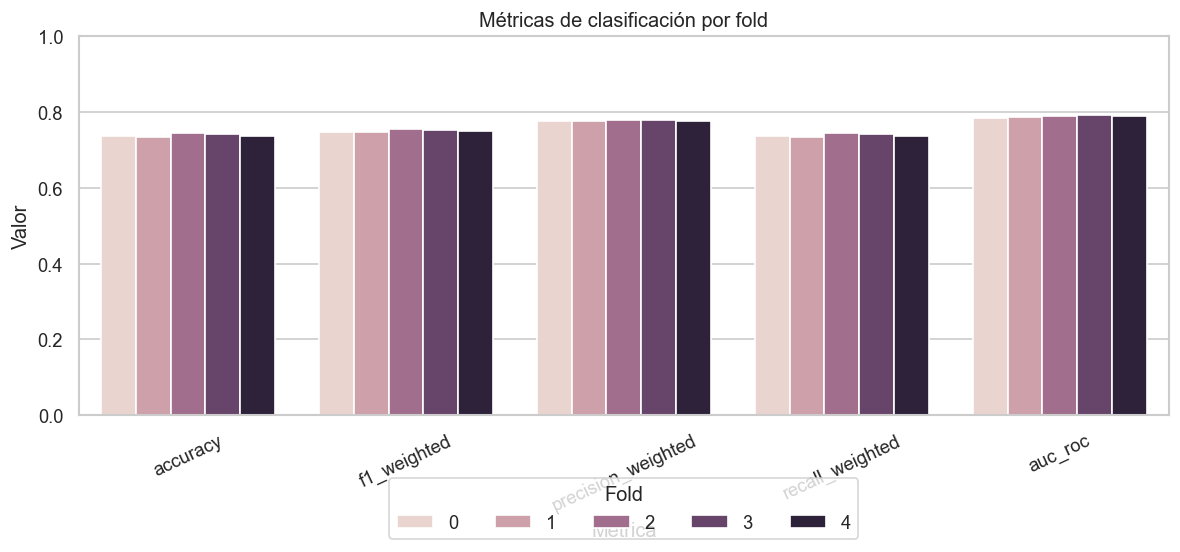

In [14]:
metrics_long = cv_metrics.melt(
    id_vars=['fold_id'],
    value_vars=metric_cols,
    var_name='metric',
    value_name='value',
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=metrics_long, x='metric', y='value', hue='fold_id', ax=ax)
ax.set_title('Métricas de clasificación por fold')
ax.set_xlabel('Métrica')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Fold', ncol=5, loc='lower center', bbox_to_anchor=(0.5, -0.35))
plt.tight_layout()
fig.savefig(ASSET_DIR / '01_metricas_por_fold.png', bbox_inches='tight')
plt.show()


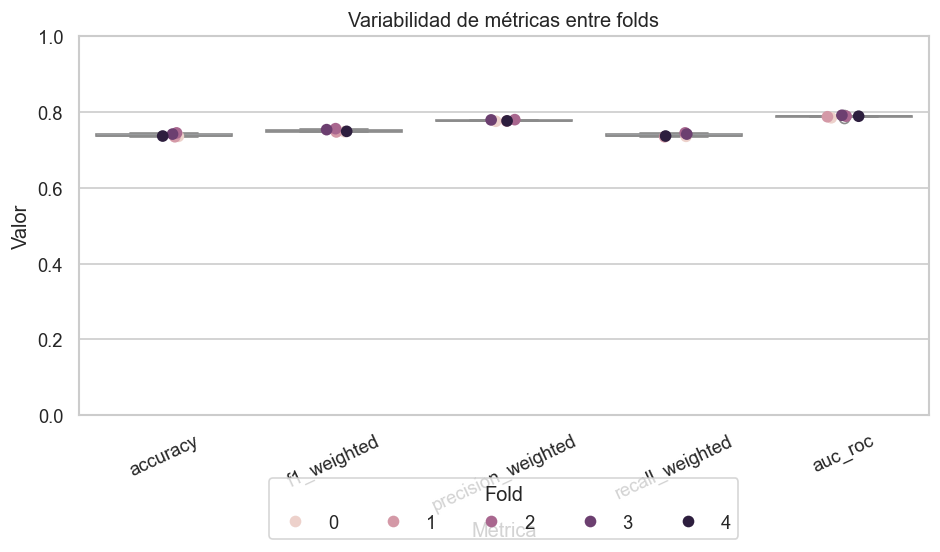

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=metrics_long, x='metric', y='value', ax=ax, color='#D9E8F5')
sns.stripplot(data=metrics_long, x='metric', y='value', hue='fold_id', ax=ax, dodge=False, size=7)
ax.set_title('Variabilidad de métricas entre folds')
ax.set_xlabel('Métrica')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Fold', ncol=5, loc='lower center', bbox_to_anchor=(0.5, -0.35))
plt.tight_layout()
fig.savefig(ASSET_DIR / '02_variabilidad_metricas.png', bbox_inches='tight')
plt.show()


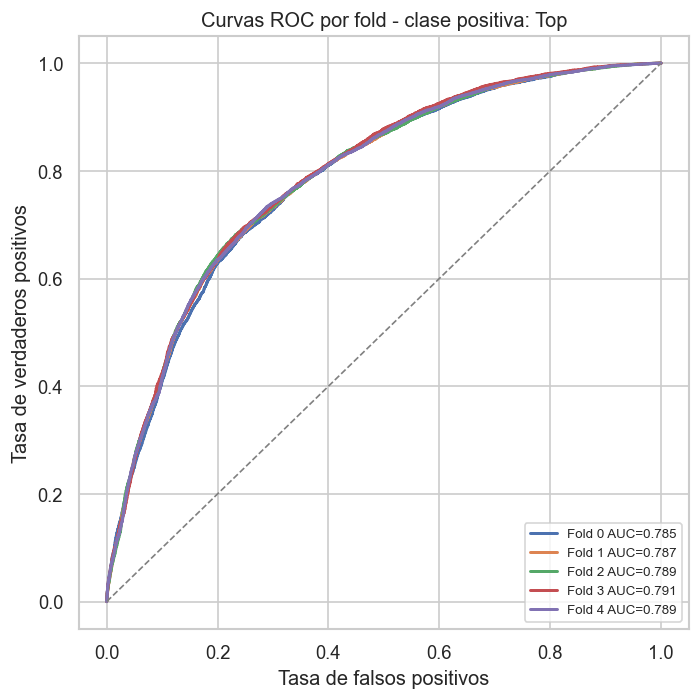

AUC promedio calculado desde curva ROC: 0.7881 ± 0.0024


In [16]:
def fallback_roc_curve(y_true, y_score):
    order = np.argsort(-y_score)
    y_true = np.asarray(y_true)[order]
    y_score = np.asarray(y_score)[order]
    positives = (y_true == positive_label).sum()
    negatives = len(y_true) - positives
    tps = np.cumsum(y_true == positive_label)
    fps = np.cumsum(y_true != positive_label)
    tpr = np.r_[0, tps / positives if positives else np.zeros_like(tps), 1]
    fpr = np.r_[0, fps / negatives if negatives else np.zeros_like(fps), 1]
    return fpr, tpr

fig, ax = plt.subplots(figsize=(6, 6))
auc_values = []
for fold_id, fold_pd in roc_all.groupby('fold_id'):
    y_true = fold_pd['label'].to_numpy()
    y_score = fold_pd['prob_positive'].to_numpy()
    if roc_curve is not None and auc is not None:
        fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=positive_label)
        fold_auc = auc(fpr, tpr)
    else:
        fpr, tpr = fallback_roc_curve(y_true, y_score)
        fold_auc = np.trapezoid(tpr, fpr)
    auc_values.append(fold_auc)
    ax.plot(fpr, tpr, lw=1.8, label=f'Fold {fold_id} AUC={fold_auc:.3f}')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1)
ax.set_title(f'Curvas ROC por fold - clase positiva: {positive_class}')
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
fig.savefig(ASSET_DIR / '03_curvas_roc.png', bbox_inches='tight')
plt.show()
print(f'AUC promedio calculado desde curva ROC: {np.mean(auc_values):.4f} ± {np.std(auc_values, ddof=1):.4f}')


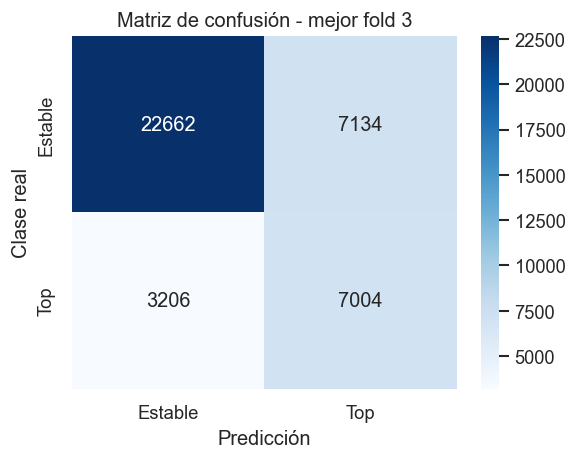

         Estable   Top
Estable    22662  7134
Top         3206  7004


In [17]:
best_confusion = (
    confusion_all[confusion_all['fold_id'] == best_fold]
    .pivot(index='label', columns='prediction', values='count')
    .fillna(0)
    .astype(int)
    .sort_index()
)
best_confusion.index = [label_names.get(float(i), str(i)) for i in best_confusion.index]
best_confusion.columns = [label_names.get(float(c), str(c)) for c in best_confusion.columns]

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(best_confusion, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'Matriz de confusión - mejor fold {best_fold}')
ax.set_xlabel('Predicción')
ax.set_ylabel('Clase real')
plt.tight_layout()
fig.savefig(ASSET_DIR / '04_matriz_confusion.png', bbox_inches='tight')
plt.show()
print(best_confusion)


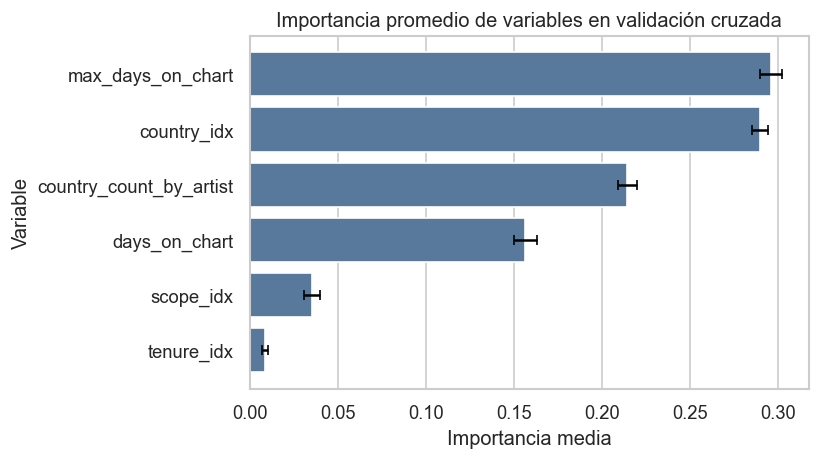

                feature   mean    std
      max_days_on_chart 0.2959 0.0062
            country_idx 0.2894 0.0046
country_count_by_artist 0.2143 0.0054
          days_on_chart 0.1563 0.0065
              scope_idx 0.0353 0.0045
             tenure_idx 0.0087 0.0019


In [18]:
feature_importance_summary = (
    feature_importance_all.groupby('feature')['importance']
    .agg(['mean', 'std'])
    .reset_index()
    .sort_values('mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=feature_importance_summary, x='mean', y='feature', ax=ax, color='#4C78A8')
ax.errorbar(
    x=feature_importance_summary['mean'],
    y=np.arange(len(feature_importance_summary)),
    xerr=feature_importance_summary['std'].fillna(0),
    fmt='none',
    ecolor='black',
    capsize=3,
)
ax.set_title('Importancia promedio de variables en validación cruzada')
ax.set_xlabel('Importancia media')
ax.set_ylabel('Variable')
plt.tight_layout()
fig.savefig(ASSET_DIR / '05_importancia_variables.png', bbox_inches='tight')
plt.show()
print(feature_importance_summary.round(4).to_string(index=False))


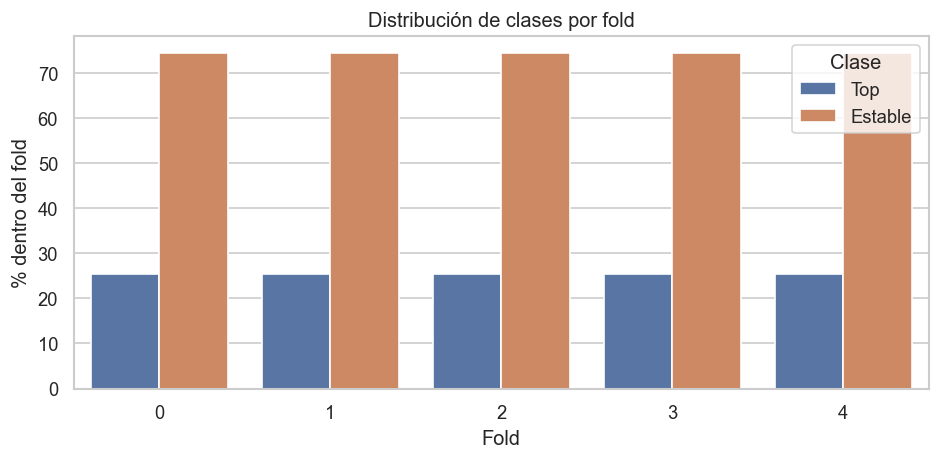

 fold_id rank_tier  count  pct_fold
       0   Estable  29799 74.478880
       0       Top  10211 25.521120
       1   Estable  29797 74.479466
       1       Top  10210 25.520534
       2   Estable  29796 74.478828
       2       Top  10210 25.521172
       3   Estable  29796 74.478828
       3       Top  10210 25.521172
       4   Estable  29796 74.482552
       4       Top  10208 25.517448


In [19]:
class_fold = (
    M_features.groupBy('fold_id', 'rank_tier').count()
    .toPandas()
)
class_fold['pct_fold'] = class_fold.groupby('fold_id')['count'].transform(lambda s: s / s.sum() * 100)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=class_fold, x='fold_id', y='pct_fold', hue='rank_tier', ax=ax)
ax.set_title('Distribución de clases por fold')
ax.set_xlabel('Fold')
ax.set_ylabel('% dentro del fold')
ax.legend(title='Clase')
plt.tight_layout()
fig.savefig(ASSET_DIR / '06_distribucion_clases_folds.png', bbox_inches='tight')
plt.show()
print(class_fold.sort_values(['fold_id', 'rank_tier']).to_string(index=False))


## 6. Modelo complementario no supervisado

`KMeans` no intenta predecir la etiqueta. Su función es explorar si permanencia, alcance y posición forman perfiles naturales. Las variables numéricas se estandarizan para evitar que una escala domine la distancia. Se comparan valores de `k` entre 2 y 6; Silhouette es el criterio principal y la inertia se reporta como apoyo. A diferencia del modelo supervisado, aquí `rank` sí puede emplearse porque no se está prediciendo `rank_tier`.

In [20]:
numeric_cols = ['days_on_chart', 'max_days_on_chart', 'country_count_by_artist', 'rank']
unsup_assembler = VectorAssembler(inputCols=numeric_cols, outputCol='raw_features')
scaler = StandardScaler(inputCol='raw_features', outputCol='features_scaled', withMean=True, withStd=True)
unsup_pipeline = Pipeline(stages=[unsup_assembler, scaler])
unsup_model = unsup_pipeline.fit(M_clean)
M_scaled = (
    unsup_model.transform(M_clean)
    .select('features_scaled', 'partition_id', *numeric_cols)
    .cache()
)
print(f'Registros para KMeans: {M_scaled.count():,}')

Registros para KMeans: 200,033


 k     inertia  silhouette
 2 541334.2097      0.4945
 3 404712.2664      0.4687
 4 325430.0644      0.4678
 5 286610.5068      0.4453
 6 251701.6931      0.4463
k seleccionado por Silhouette: 2


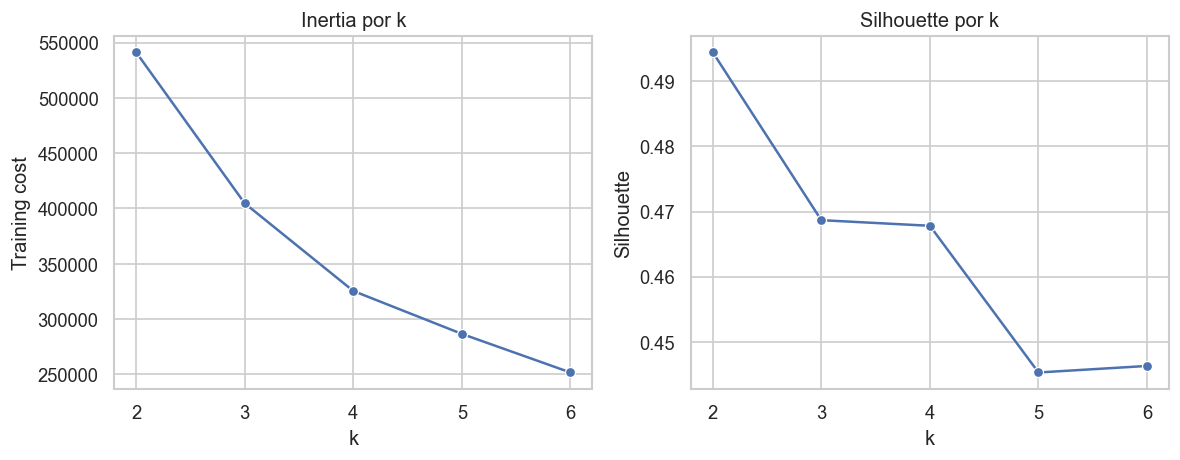

In [21]:
cluster_evaluator = ClusteringEvaluator(
    featuresCol='features_scaled',
    metricName='silhouette',
    distanceMeasure='squaredEuclidean',
)
cluster_rows = []
for k in range(2, 7):
    km = KMeans(featuresCol='features_scaled', k=k, seed=SEED, maxIter=30)
    model_k = km.fit(M_scaled)
    pred_k = model_k.transform(M_scaled)
    cluster_rows.append({
        'k': k,
        'inertia': float(model_k.summary.trainingCost),
        'silhouette': float(cluster_evaluator.evaluate(pred_k)),
    })

k_results = pd.DataFrame(cluster_rows)
best_k = int(k_results.loc[k_results['silhouette'].idxmax(), 'k'])
print(k_results.round(4).to_string(index=False))
print(f'k seleccionado por Silhouette: {best_k}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.lineplot(data=k_results, x='k', y='inertia', marker='o', ax=axes[0])
axes[0].set_title('Inertia por k')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Training cost')
sns.lineplot(data=k_results, x='k', y='silhouette', marker='o', ax=axes[1])
axes[1].set_title('Silhouette por k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
fig.savefig(ASSET_DIR / '07_seleccion_kmeans.png', bbox_inches='tight')
plt.show()

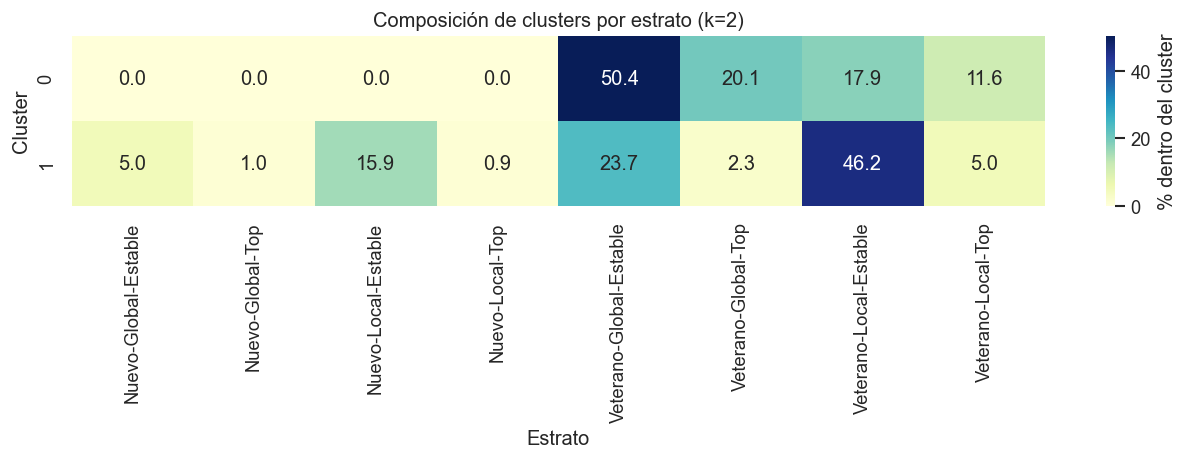

Silhouette final: 0.4945
Inertia final: 541,334

Tamaños de cluster:
 prediction  count   pct
          0 145069 72.52
          1  54964 27.48

Centroides en escala original:
 cluster  days_on_chart  max_days_on_chart  country_count_by_artist   rank  count   pct
       0         857.16            1610.45                    35.86  87.22 145069 72.52
       1         275.12             773.45                    11.58 131.44  54964 27.48


In [22]:
kmeans_model = KMeans(
    featuresCol='features_scaled',
    k=best_k,
    seed=SEED,
    maxIter=50,
).fit(M_scaled)
clusters = kmeans_model.transform(M_scaled).cache()
silhouette_final = float(cluster_evaluator.evaluate(clusters))
inertia_final = float(kmeans_model.summary.trainingCost)

cluster_sizes = clusters.groupBy('prediction').count().orderBy('prediction').toPandas()
cluster_sizes['pct'] = cluster_sizes['count'] / cluster_sizes['count'].sum() * 100

scaler_model = unsup_model.stages[1]
means = scaler_model.mean.toArray()
stds = scaler_model.std.toArray()
centers_original = np.array(kmeans_model.clusterCenters()) * stds + means
centers_df = pd.DataFrame(centers_original, columns=numeric_cols)
centers_df.index.name = 'cluster'
centers_df = centers_df.reset_index().merge(
    cluster_sizes.rename(columns={'prediction': 'cluster'}),
    on='cluster',
)

cluster_partition = (
    clusters.groupBy('prediction', 'partition_id').count().toPandas()
    .pivot(index='prediction', columns='partition_id', values='count')
    .fillna(0).astype(int).sort_index()
)
cluster_partition_pct = cluster_partition.div(cluster_partition.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(cluster_partition_pct, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax, cbar_kws={'label': '% dentro del cluster'})
ax.set_title(f'Composición de clusters por estrato (k={best_k})')
ax.set_xlabel('Estrato')
ax.set_ylabel('Cluster')
plt.tight_layout()
fig.savefig(ASSET_DIR / '08_composicion_clusters.png', bbox_inches='tight')
plt.show()

print(f'Silhouette final: {silhouette_final:.4f}')
print(f'Inertia final: {inertia_final:,.0f}')
print('\nTamaños de cluster:')
print(cluster_sizes.round(2).to_string(index=False))
print('\nCentroides en escala original:')
print(centers_df.round(2).to_string(index=False))

## 7. Discusión, conclusiones y trabajo futuro

La construcción estratificada de `M` conserva los ocho perfiles definidos por antigüedad, alcance y visibilidad competitiva. La asignación cíclica dentro de cada estrato produce folds prácticamente iguales y evita que la evaluación dependa de una partición accidental. El control de fuga es central: `rank` se utiliza para construir la etiqueta, pero se excluye del bosque aleatorio.

El ajuste de hiperparámetros permite seleccionar una complejidad sustentada por resultados de validación. La lectura principal combina AUC-ROC, F1 ponderado y su desviación entre folds. Una desviación baja indica que el patrón aprendido es estable. La matriz de confusión muestra qué clase concentra los errores y la importancia de variables permite interpretar qué señales de trayectoria y alcance contribuyen a la clasificación.

La comparación contra la línea base mayoritaria es indispensable. Como la clase `Estable` domina la muestra, predecir siempre esa clase puede obtener una accuracy competitiva sin recuperar ningún caso `Top`. Por eso, si Random Forest sacrifica ligeramente accuracy pero mejora F1 y logra recall útil para `Top`, el resultado debe interpretarse como un intercambio deliberado entre desempeño global y recuperación de la clase minoritaria, no como una victoria en todas las métricas.

KMeans complementa la clasificación al descubrir perfiles sin usar etiquetas. Silhouette evalúa separación y cohesión, mientras que los centroides traducen cada cluster a escalas comprensibles. La coincidencia parcial entre clusters y estratos confirma que la estructura del mercado no depende de una sola variable, aunque las agrupaciones no deben interpretarse como segmentos causales.

### Limitaciones

- La tarea es explicativa y contemporánea; no constituye un pronóstico temporal.
- Los registros de un mismo artista pueden aparecer en distintos folds, por lo que la validación mide generalización entre observaciones, no necesariamente hacia artistas nunca vistos.
- País se codifica como categoría indexada; una representación futura podría incorporar región, tamaño de mercado o variables temporales.
- El muestreo reduce costo computacional, pero no sustituye una infraestructura distribuida cuando se desea entrenar sobre la población completa.

### Conclusiones

El proyecto demuestra un flujo reproducible de aprendizaje sobre millones de registros: auditoría, delimitación de población, muestreo representativo, preparación sin fuga, ajuste de hiperparámetros, validación cruzada, visualización e interpretación. El bosque aleatorio proporciona una separación útil entre observaciones `Top` y `Estable`, y la baja variabilidad entre folds permite juzgar su estabilidad. El análisis no supervisado añade una lectura complementaria de perfiles de permanencia y alcance.

### Trabajo futuro

Se recomienda implementar una división temporal, agrupar folds por artista para medir generalización a entidades no vistas, comparar con Gradient-Boosted Trees o regresión logística, y agregar variables históricas que sólo utilicen información disponible antes de cada fecha.

In [23]:
REPORT_DIR.mkdir(exist_ok=True)
ASSET_DIR.mkdir(exist_ok=True)

strata_compare.to_csv(REPORT_DIR / 'tabla_estratos.csv', index=False)
fold_counts.to_csv(REPORT_DIR / 'tabla_folds.csv', index=False)
tuning_results.to_csv(REPORT_DIR / 'tabla_hiperparametros.csv', index=False)
cv_metrics.to_csv(REPORT_DIR / 'tabla_metricas_folds.csv', index=False)
baseline_metrics.to_csv(REPORT_DIR / 'tabla_linea_base_folds.csv', index=False)
model_vs_baseline.to_csv(REPORT_DIR / 'tabla_modelo_vs_linea_base.csv', index=False)
per_class_metrics.to_csv(REPORT_DIR / 'tabla_metricas_por_clase.csv', index=False)
summary_stats.to_csv(REPORT_DIR / 'tabla_resumen_metricas.csv', index=False)
best_confusion.to_csv(REPORT_DIR / 'tabla_matriz_confusion.csv')
feature_importance_summary.to_csv(REPORT_DIR / 'tabla_importancia_variables.csv', index=False)
k_results.to_csv(REPORT_DIR / 'tabla_kmeans.csv', index=False)
cluster_sizes.to_csv(REPORT_DIR / 'tabla_tamanos_clusters.csv', index=False)
centers_df.to_csv(REPORT_DIR / 'tabla_centroides_clusters.csv', index=False)

final_metrics = {
    'dataset': {
        'original_records': int(n_original),
        'date_min': str(date_bounds.min_date),
        'date_max': str(date_bounds.max_date),
        'filtered_records': int(n_total),
        'excluded_country': 'VE',
        'evaluation_start': '2022-10-21',
    },
    'sample': {
        'target': TARGET_N,
        'actual': int(n_M),
        'clean': int(n_M_clean),
        'strata': int(strata_pd['partition_id'].nunique()),
        'max_population_sample_difference_pct': float(strata_compare['abs_diff_pct'].max()),
    },
    'folds': {
        'count': K_FOLDS,
        'minimum_size': int(fold_counts['count'].min()),
        'maximum_size': int(fold_counts['count'].max()),
    },
    'random_forest': {
        'selected_numTrees': int(best_params['numTrees']),
        'selected_maxDepth': int(best_params['maxDepth']),
        'best_fold': int(best_fold),
        'best_fold_selection_rule': 'AUC-ROC descending, weighted F1 descending as tie-breaker',
        'metrics_mean': {m: float(cv_metrics[m].mean()) for m in metric_cols},
        'metrics_std': {m: float(cv_metrics[m].std(ddof=1)) for m in metric_cols},
        'baseline_mean': {m: float(baseline_metrics[m].mean()) for m in metric_cols},
        'model_minus_baseline': {
            m: float(cv_metrics[m].mean() - baseline_metrics[m].mean())
            for m in metric_cols
        },
        'per_class': {
            row['class']: {
                'support': int(row['support']),
                'precision': float(row['precision']),
                'recall': float(row['recall']),
                'f1': float(row['f1']),
            }
            for row in per_class_rows
        },
    },
    'kmeans': {
        'best_k': int(best_k),
        'silhouette': silhouette_final,
        'inertia': inertia_final,
    },
    'integrity': {
        'all_eight_strata': bool(strata_pd['partition_id'].nunique() == 8 and sample_strata['partition_id'].nunique() == 8),
        'five_balanced_folds': bool(int(fold_counts['count'].max() - fold_counts['count'].min()) <= 10),
        'unique_ids': bool(M_clean.select('id').distinct().count() == n_M_clean),
        'rank_excluded_from_supervised_features': bool('rank' not in feature_cols),
    },
}

with open(REPORT_DIR / 'final_metrics.json', 'w', encoding='utf-8') as handle:
    json.dump(final_metrics, handle, ensure_ascii=False, indent=2)

print(json.dumps(final_metrics, ensure_ascii=False, indent=2))

{
  "dataset": {
    "original_records": 22711258,
    "date_min": "2021-10-21",
    "date_max": "2026-05-02",
    "filtered_records": 17914239,
    "excluded_country": "VE",
    "evaluation_start": "2022-10-21"
  },
  "sample": {
    "target": 200000,
    "actual": 200033,
    "clean": 200033,
    "strata": 8,
    "max_population_sample_difference_pct": 0.18642946200952415
  },
  "folds": {
    "count": 5,
    "minimum_size": 40004,
    "maximum_size": 40010
  },
  "random_forest": {
    "selected_numTrees": 100,
    "selected_maxDepth": 8,
    "best_fold": 3,
    "best_fold_selection_rule": "AUC-ROC descending, weighted F1 descending as tie-breaker",
    "metrics_mean": {
      "accuracy": 0.7385481964800166,
      "f1_weighted": 0.7506081589026484,
      "precision_weighted": 0.7772269506634156,
      "recall_weighted": 0.7385481964800165,
      "auc_roc": 0.7880929676855818
    },
    "metrics_std": {
      "accuracy": 0.004353583084427793,
      "f1_weighted": 0.003758830960026696

## 8. Reproducibilidad y comprobación de la rúbrica

### Reproducción

1. Colocar `charts_artists_daily.csv` dentro de `spotify_project/raw/`.
2. Usar Java 17 y el kernel `pyspark-notebook`.
3. Ejecutar el notebook completo desde la raíz del proyecto.
4. Verificar que `report/final_metrics.json`, las tablas CSV y las ocho figuras sean generadas.

Comando utilizado:

```bash
JAVA_HOME=/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home jupyter nbconvert --to notebook --execute --inplace notebooks/ProyectoFinal_Equipo51.ipynb --ExecutePreprocessor.kernel_name=pyspark-notebook --ExecutePreprocessor.timeout=3600
```

### Evidencia de cumplimiento

| Requisito | Evidencia |
|---|---|
| Lectura del dataset original | Sección 1, esquema y auditoría |
| Caracterización y muestra | Sección 2, ocho estratos y comparación P vs M |
| Preparación de datos | Sección 3, pipeline y exclusión de `rank` |
| Métricas e hiperparámetros | Sección 4, cuatro configuraciones comparadas |
| Modelos de aprendizaje | Secciones 5 y 6, Random Forest y KMeans |
| Experimentación y resultados | Cinco folds, métricas, ROC, matriz de confusión y clustering |
| Discusión y conclusiones | Sección 7 |
| Código documentado y organizado | Secciones numeradas, assertions y exportación reproducible |

In [24]:
M_scaled.unpersist()
clusters.unpersist()
spark.stop()
print('Ejecución finalizada correctamente.')

Ejecución finalizada correctamente.
